# Генерация синтетических данных с использованием Faker

In [18]:
!pip install faker

zsh:1: command not found: pip


In [29]:
import pandas as pd
import random
import json
from faker import Faker
from datetime import datetime, timedelta
from owlready2 import *

In [30]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # фиксируем seed для воспроизводимости
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [21]:
# DataFrame с отделами
def generate_departments(n):
   
    departments = []
    for i in range(1, n + 1):
        departments.append({
            'department_id': i,
            'name': fake.unique.job() + ' отдел',  # уникальное название
            'location': fake.city()
        })
    return pd.DataFrame(departments)

# DataFrame с должностями и диапазоном зарплат
def generate_positions(n: int) -> pd.DataFrame:
    
    positions = []
    for i in range(1, n + 1):
        min_salary = random.randint(30000, 60000)
        max_salary = min_salary + random.randint(20000, 80000)
        positions.append({
            'position_id': i,
            'name': fake.unique.job(),
            'min_salary': min_salary,
            'max_salary': max_salary
        })
    return pd.DataFrame(positions)

# генерируем сотрудников со случайными атрибутами
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    
    employees = []
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        phone = fake.phone_number()
        email = fake.email()
        address = fake.address().replace('\n', ', ')
        
        # дата найма: не раньше 18-летия и не позже сегодняшнего дня
        min_hire_date = birth_date + timedelta(days=18*365)
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # статус -  active / terminated (10% уволены)
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # выбор отдела и должности
        department_id = random.choice(department_ids)
        position_id = random.choice(position_ids)
        
        # зарплата     
        salary = random.randint(40000, 150000)
        
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']),
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
    return pd.DataFrame(employees)

# создать историю зарплат на основе данных сотрудников
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    history = []
    record_id = 1
    
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        hire_date = emp['hire_date']
        current_salary = emp['salary']
        
        # количество изменений (0 – если сотрудник только нанят и ещё не было изменений)
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # генерируем даты изменений (после hire_date и до сегодня)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # начальная зарплата при найме (можно сделать немного отличающейся от текущей)
        #  будем считать, что первая запись – это зарплата при найме,
        # а последующие – повышения.
        if num_changes == 0:
            # Если изменений не было, всё равно добавим одну запись (начальная)
            history.append({
                'history_id': record_id,
                'employee_id': emp_id,
                'change_date': hire_date,
                'new_salary': current_salary
            })
            record_id += 1
        else:
            # генерируем возрастающие зарплаты
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            # добавляем текущую зарплату как последнюю
            salary_values.append(current_salary)
            # даты: hire_date и change_dates
            all_dates = [hire_date] + change_dates
            for i in range(len(all_dates)):
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],
                    'new_salary': salary_values[i]
                })
                record_id += 1
    return pd.DataFrame(history)

In [22]:
N_DEPARTMENTS = 10
N_POSITIONS = 20
N_EMPLOYEES = 500

In [23]:
departments_df = generate_departments(N_DEPARTMENTS)
positions_df = generate_positions(N_POSITIONS)
employees_df = generate_employees(
    N_EMPLOYEES,
    departments_df['department_id'].tolist(),
    positions_df['position_id'].tolist()
)

In [24]:
departments_df

,department_id,name,location
0,1,Диетолог отдел,клх Кырен
1,2,Метеоролог отдел,п. Волоколамск
2,3,Гепатолог отдел,г. Артем
3,4,Гомеопат отдел,п. Териберка
4,5,Бактериолог отдел,клх Усинск
5,6,Танцор отдел,с. Чикола
6,7,Нотариус отдел,ст. Ессентуки
7,8,Тележурналист отдел,к. Ельня
8,9,Литейщик отдел,г. Видное
9,10,Сиделка отдел,к. Нефедова


In [25]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Мясник,50952,78248
1,2,Борт-радист,30819,99417
2,3,Философ,39012,75061
3,4,Доярка,37314,66458
4,5,Семейный врач,54132,80849
5,6,Врач скорой помощи,52174,120714
6,7,Ортопед,59234,114975
7,8,Реставратор,32848,91546
8,9,Композитор,43825,65907
9,10,Военный прокурор,30976,57116


In [26]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1969-08-17,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,1997-10-28,active,7,11,76421
1,2,Гордеев,Фотий,Владимировна,1976-08-23,Ж,"д. Александров Гай, бул. Донской, д. 6 стр. 34...",+7 (287) 101-2269,blinovnaum@example.net,2022-05-09,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1982-05-20,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",+7 (252) 880-9570,gushchinmitofan@example.com,2025-07-19,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,1992-01-16,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+76578713315,safonovataisija@example.org,2019-07-04,active,9,4,89615
4,5,Капустина,Илья,Харламович,1998-04-11,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",+7 (116) 566-7010,varhipova@example.org,2020-05-31,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Зыкова,Изот,Владленович,1972-09-15,Ж,"п. Палана, алл. Южная, д. 5 к. 8, 279970",8 398 358 4461,marfa2006@example.net,1997-05-18,active,4,16,112173
496,497,Бобылев,Демид,Арсеньевич,1964-01-25,М,"п. Ноглики, бул. Трактовый, д. 12 к. 848, 888975",8 397 871 3752,spartak_1983@example.org,2012-06-03,active,8,16,100401
497,498,Овчинникова,Иванна,Ниловна,1992-11-03,Ж,"г. Сковородино, наб. Тополиная, д. 29, 292950",8 852 386 0030,ladislav36@example.net,2012-04-10,active,6,6,58344
498,499,Пестов,Евстафий,Елизарович,1990-02-16,М,"г. Яшкуль, бул. Деповский, д. 232, 672019",8 (309) 309-6713,vadim2004@example.org,2022-04-12,active,9,2,108674


In [27]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

,history_id,employee_id,change_date,new_salary
0,1,1,1997-10-28,71333
1,2,1,2013-10-28,76421
2,3,2,2022-05-09,34948
3,4,2,2023-12-24,52156
4,5,3,2025-07-19,74671
...,...,...,...,...
1291,1292,498,2024-08-02,57426
1292,1293,498,2025-05-26,58344
1293,1294,499,2022-04-12,89827
1294,1295,499,2025-04-07,108674


In [28]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.


### Вариант 1. Аренда электромобилей
Сущности: 
- Автомобиль: id, марка, модель, год выпуска, госномер, запас хода (км), статус (доступен, арендован, на обслуживании), тариф (цена за минуту), локация (парковка). История зарядок (JSON-массив объектов: {id станции, дата_начала, дата_конца, объём_кВт·ч, стоимость}).
- Клиент: id, ФИО, водительское удостоверение (серия, номер), телефон, email, дата регистрации.
- Аренда:id, id клиента, id автомобиля, дата и время начала, дата и время окончания, начальный пробег, конечный пробег, стоимость, статус (активна, завершена, отменена), Информация об оплате (поля внутри таблицы): сумма, способ оплаты, дата оплаты, статус оплаты.
- Зарядная станция: id, адрес, тип разъёма, количество мест, статус (работает/не работает).

Объём данных: автомобили - 100, клиенты - 500, аренды - 3000, зарядные станции -  20

Онтология:
- Классы: Автомобиль, Клиент, Аренда, ЗаряднаяСтанция.
- Связи:  клиент арендует автомобиль, автомобиль участвует в арендах, история зарядок хранится в JSON внутри автомобиля, ссылаясь на станции, Аренда содержит данные об оплате.

### Вариант 2. Банковские клиенты и транзакции
Сущности: 
- Клиент: id, ФИО, дата рождения, паспортные данные (серия, номер, кем выдан), адрес, телефон, email.
- Счёт: id, номер счёта, тип (дебетовый/кредитный), валюта, дата открытия, остаток, id клиента.
- Транзакция: id, дата, сумма, тип (пополнение/списание), id счёта, описание.
- Кредит: id, id клиента, сумма, процентная ставка, срок, дата выдачи, ежемесячный платёж.

Объём: 1000 клиентов, у каждого 1–3 счёта, на каждом 10–50 транзакций, 20% клиентов имеют кредиты.

Онтология:
- Классы: Клиент, Счёт, Транзакция, Кредит.
- Связи: клиент владеет счетами, по счетам проходят транзакции, клиент может иметь кредиты.

### Вариант 3. Медицинские пациенты и приёмы
Сущности:
- Пациент: id, ФИО, дата рождения, пол, полис ОМС, СНИЛС, адрес, телефон.
- Врач: id, ФИО, специальность, кабинет.
- Приём: id, дата и время, id пациента, id врача, диагноз (код МКБ-10), жалобы, назначения (JSON-массив объектов: {лекарство, дозировка, курс}).
- Больничный лист: id, id приёма, дата начала, дата окончания, диагноз.

Объём: 2000 пациентов, 50 врачей, 5–10 приёмов на пациента за последние 2 года, часть с больничными.

Онтология:
- Классы: Пациент, Врач, Приём, БольничныйЛист.
- Связи: пациент посещает врача (приём), по приёму может быть открыт больничный, назначения хранятся в JSON приёма (Атрибут класса Прием).

### Вариант 4. Студенты и успеваемость
Сущности:
- Студент: id, ФИО, дата рождения, группа, год поступления, форма обучения.
- Группа: id, номер, курс, институт, направление подготовки.
- Предмет: id, название, семестр, количество часов, форма контроля (экзамен/зачёт), id преподавателя.
- Оценка: id, id студента, id предмета, дата, оценка (число или зачёт/незачёт).
- Преподаватель: id, ФИО, кафедра.

Объём: 10 групп по 25 студентов = 250 студентов, 30 предметов, у каждого студента оценки по всем предметам (≈ 7500 записей).

Онтология
- Классы: Студент, Группа, Предмет, Оценка, Преподаватель.
- Связи: студент учится в группе, группа изучает предметы (связка группа-предмет), преподаватель ведёт предмет, студент получает оценки.

### Вариант 5. Интернет-магазин: товары, заказы, покупатели
Сущности:
- Покупатель: id, email, ФИО, телефон, дата регистрации.
- Товар: id, название, категория, цена, остаток на складе.
- Заказ: id, id покупателя, дата, статус (новый, оплачен, отгружен, доставлен).
- Состав заказа: id заказа, id товара, количество, цена в момент заказа.
- Отзыв: id, id покупателя, id товара, оценка (1–5), текст, дата.

Объём: 500 покупателей, 1000 товаров, 3000 заказов (в среднем по 2 товара в заказе), 1500 отзывов.

Онтология:
- Классы: Покупатель, Товар, Заказ, СтрокаЗаказа, Отзыв.
- Связи: покупатель делает заказ, заказ содержит товары (с количеством), покупатель оставляет отзыв на товар.

### Вариант 6. Недвижимость и сделки
Сущности: 
- Объект недвижимости: id, адрес, тип (квартира/дом/коммерческое), площадь, количество комнат, этаж, год постройки, кадастровый номер.
- Владелец: id, ФИО, паспортные данные, доля (если долевая собственность).
- Сделка купли-продажи: id, дата, id объекта, id продавца, id покупателя, цена, нотариус.
- Ценовой архив: id объекта, дата изменения, новая цена (для отслеживания динамики).

Объём: 2000 объектов, 300 владельцев, 150 сделок, у каждого объекта 2–3 записи цен.

Онтология:
- Классы: Объект, Владелец, Сделка, ЦеновойАрхив.
- Связи: объект может иметь нескольких владельцев (доли), сделка связывает продавца, покупателя и объект.

### Вариант 7. Транспортные средства и штрафы
Сущности:
- Владелец ТС: id, ФИО, водительское удостоверение (серия, номер), адрес, телефон.
- Автомобиль: id, госномер, марка, модель, год выпуска, VIN, цвет, id владельца.
- Штраф: id, id автомобиля, дата, статья нарушения, сумма, статус (оплачен/не оплачен).
- Страховой полис: id, id автомобиля, компания, дата начала, дата окончания, стоимость.

Объём: 1000 владельцев, 1200 автомобилей (некоторые владеют несколькими), 5000 штрафов, 1500 полисов.

Онтология:
- Классы: Владелец, Автомобиль, Штраф, Полис.
- Связи: владелец владеет автомобилями, автомобиль имеет штрафы и страховки.

### Вариант 8. Библиотека: книги, читатели, выдачи
Сущности:
- Книга: id, ISBN, название, автор, год издания, издательство, жанр, количество экземпляров в библиотеке.
- Читатель: id, ФИО, дата рождения, адрес, телефон, email, дата регистрации.
- Выдача: id, id книги, id читателя, дата выдачи, дата возврата (если есть), фактическая дата возврата.
- Бронь: id, id книги, id читателя, дата брони, статус (активна/исполнена).

Объём: 500 книг, 300 читателей, 2000 выдач, 100 броней.

Онтология:
- Классы: Книга, Читатель, Выдача, Бронь.
- Связи: читатель берёт книгу (выдача), может бронировать.

### Вариант 9. Техподдержка: заявки и обращения
Сущности:
- Пользователь: id, ФИО, email, телефон, уровень (обычный/премиум).
- Категория заявки: id, название, описание.
- Сотрудник поддержки: id, ФИО, отдел, количество решённых заявок.
- Заявка: id, id пользователя, id категории, тема, описание, дата создания, статус (новая, в работе, решена, закрыта), приоритет, id сотрудника (назначен), комментарии (JSON-массив объектов: {id автора (пользователь или сотрудник), текст, дата}).

Объём данных: пользователи - 1000, категории - 5, сотрудники - 10, заявки - 5000, комментарии - 15 000  (общее на все заявки)

Онтология:
- Классы: Пользователь, Категория, Сотрудник, Заявка.
- Связи: пользователь создаёт заявку; заявка относится к категории; заявка назначается сотруднику; комментарии принадлежат заявке (в JSON).

### Вариант 10. Доставка обедов из ресторанов
Сущности: 
- Ресторан: id, название, адрес, кухня (тип кухни), рейтинг.
- Блюдо: id, название, id ресторана, категория, цена, вес/порция, калории.
- Клиент: id, ФИО, телефон, email, адрес доставки (основной), дата регистрации.
- Заказ: id, id клиента, id ресторана, дата и время заказа, статус (принят, готовится, доставлен, отменён), общая сумма, способ оплаты, состав заказа (JSON-массив объектов: {id блюда, количество, цена_в_момент_заказа}), информация о доставке (поля внутри той же таблицы): курьер (ФИО), дата и время назначения курьера, дата и время фактической доставки, статус доставки (назначен, в пути, выполнен), фактический адрес доставки (если отличается от адреса клиента)

Объём данных: рестораны -  20, блюда - в среднем 20 на ресторан, клиенты -  1000, заказы - 5000.

Онтология: 
- Классы: Ресторан, Блюдо, Клиент, Заказ.
- Связи: ресторан предлагает блюда, клиент оформляет заказ, заказ ссылается на ресторан и клиента.

Состав заказа и данные доставки хранятся внутри сущности «Заказ» (денормализовано с использованием JSON).


### Вариант 9. Техподдержка: заявки и обращения. Решение

In [31]:
def generate_users(n: int) -> pd.DataFrame:
    users = []

    for user_id in range(1, n + 1):
        users.append({
            "user_id": user_id,
            "full_name": fake.name(),
            "email": fake.unique.email(),
            "phone": fake.phone_number(),
            "level": random.choices(
                ["обычный", "премиум"],
                weights=[0.8, 0.2]
            )[0]
        })

    return pd.DataFrame(users)

In [32]:
def generate_categories() -> pd.DataFrame:
    categories = [
        {
            "category_id": 1,
            "name": "Проблемы со входом",
            "description": "Ошибки авторизации, восстановление пароля, блокировка аккаунта"
        },
        {
            "category_id": 2,
            "name": "Технический сбой",
            "description": "Ошибки системы, недоступность сервиса, сбои в работе"
        },
        {
            "category_id": 3,
            "name": "Оплата и подписка",
            "description": "Проблемы со списанием средств, тарифами и подписками"
        },
        {
            "category_id": 4,
            "name": "Функциональные вопросы",
            "description": "Вопросы по использованию возможностей системы"
        },
        {
            "category_id": 5,
            "name": "Жалобы и предложения",
            "description": "Обратная связь, жалобы, улучшения сервиса"
        }
    ]

    return pd.DataFrame(categories)

In [33]:
def generate_support_staff(n: int) -> pd.DataFrame:
    departments = [
        "Первая линия",
        "Технический отдел",
        "Финансовая поддержка",
        "Отдел качества",
        "VIP-поддержка"
    ]

    staff = []

    for staff_id in range(1, n + 1):
        staff.append({
            "staff_id": staff_id,
            "full_name": fake.name(),
            "department": random.choice(departments),
            "resolved_tickets_count": 0
        })

    return pd.DataFrame(staff)

In [34]:
N_USERS = 1000
N_STAFF = 10

users_df = generate_users(N_USERS)
categories_df = generate_categories()
support_staff_df = generate_support_staff(N_STAFF)

users_df.head()

,user_id,full_name,email,phone,level
0,1,Козлова Ирина Ефимовна,visheslavzinovev@example.org,8 (196) 001-3389,обычный
1,2,Лазарев Трифон Федосеевич,prohorsafonov@example.com,+7 265 423 5116,обычный
2,3,Сазонов Мечислав Евсеевич,artemevaoksana@example.net,+7 618 495 93 10,обычный
3,4,Мамонтова Кира Артемовна,varlaamshcherbakov@example.com,8 (525) 534-19-28,обычный
4,5,Сорокина Октябрина Мироновна,alla83@example.net,8 030 564 1395,обычный


In [35]:
categories_df

,category_id,name,description
0,1,Проблемы со входом,"Ошибки авторизации, восстановление пароля, бло..."
1,2,Технический сбой,"Ошибки системы, недоступность сервиса, сбои в ..."
2,3,Оплата и подписка,"Проблемы со списанием средств, тарифами и подп..."
3,4,Функциональные вопросы,Вопросы по использованию возможностей системы
4,5,Жалобы и предложения,"Обратная связь, жалобы, улучшения сервиса"


In [36]:
support_staff_df.head()


,staff_id,full_name,department,resolved_tickets_count
0,1,Савельева Акулина Святославовна,Первая линия,0
1,2,Феврония Тимофеевна Молчанова,Финансовая поддержка,0
2,3,Маслова Варвара Робертовна,VIP-поддержка,0
3,4,Аркадий Трофимович Самойлов,Финансовая поддержка,0
4,5,Жанна Ниловна Михеева,Первая линия,0


In [37]:
def generate_comments(user_id: int, staff_ids: list, n_comments: int) -> str:
    comments = []

    for _ in range(n_comments):
        author_type = random.choice(["user", "staff"])

        if author_type == "user":
            author_id = user_id
        else:
            author_id = random.choice(staff_ids)

        comments.append({
            "author_id": author_id,
            "author_type": author_type,
            "text": fake.sentence(nb_words=8),
            "date": fake.date_time_between(start_date="-1y", end_date="now").strftime("%Y-%m-%d %H:%M:%S")
        })

    return json.dumps(comments, ensure_ascii=False)

In [38]:
def generate_tickets(n: int, users_df: pd.DataFrame, categories_df: pd.DataFrame, support_staff_df: pd.DataFrame) -> pd.DataFrame:
    tickets = []

    user_ids = users_df["user_id"].tolist()
    category_ids = categories_df["category_id"].tolist()
    staff_ids = support_staff_df["staff_id"].tolist()

    statuses = ["новая", "в работе", "решена", "закрыта"]
    priorities = ["низкий", "средний", "высокий", "критический"]

    for ticket_id in range(1, n + 1):
        user_id = random.choice(user_ids)
        category_id = random.choice(category_ids)

        status = random.choices(
            statuses,
            weights=[0.15, 0.25, 0.35, 0.25]
        )[0]

        priority = random.choices(
            priorities,
            weights=[0.2, 0.4, 0.3, 0.1]
        )[0]

        created_at = fake.date_time_between(start_date="-2y", end_date="now")

        if status == "новая":
            staff_id = None
        else:
            staff_id = random.choice(staff_ids)

        n_comments = random.randint(1, 5)
        comments_json = generate_comments(user_id, staff_ids, n_comments)

        tickets.append({
            "ticket_id": ticket_id,
            "user_id": user_id,
            "category_id": category_id,
            "subject": fake.sentence(nb_words=5),
            "description": fake.text(max_nb_chars=200),
            "created_at": created_at.strftime("%Y-%m-%d %H:%M:%S"),
            "status": status,
            "priority": priority,
            "staff_id": staff_id,
            "comments_json": comments_json
        })

    return pd.DataFrame(tickets)

In [39]:
N_TICKETS = 5000

tickets_df = generate_tickets(
    N_TICKETS,
    users_df,
    categories_df,
    support_staff_df
)

tickets_df.head()

,ticket_id,user_id,category_id,subject,description,created_at,status,priority,staff_id,comments_json
0,1,94,2,Сверкающий июнь невыносимый отражение одиннадц...,Привлекать угодный юный помимо вздрагивать. Яр...,2026-01-13 07:29:23,решена,средний,1.0,"[{""author_id"": 4, ""author_type"": ""staff"", ""tex..."
1,2,129,5,Порядок функция перебивать еврейский рай разно...,Интернет витрина порог падать за пятеро.\nО ра...,2025-07-26 21:04:35,в работе,высокий,9.0,"[{""author_id"": 129, ""author_type"": ""user"", ""te..."
2,3,337,2,Командир научить приятель карман иной.,Горький танцевать терапия проход бабочка. Непр...,2025-12-04 05:36:36,закрыта,средний,5.0,"[{""author_id"": 337, ""author_type"": ""user"", ""te..."
3,4,113,1,Отражение конференция покидать плясать понятны...,Забирать неправда сопровождаться зарплата поро...,2024-10-11 20:42:23,новая,средний,NaN,"[{""author_id"": 1, ""author_type"": ""staff"", ""tex..."
4,5,272,1,Вскинуть деловой мучительно издали.,Трясти разнообразный около монета инвалид дрем...,2025-08-26 19:45:14,новая,средний,NaN,"[{""author_id"": 272, ""author_type"": ""user"", ""te..."


In [40]:
resolved_counts = (
    tickets_df[tickets_df["status"].isin(["решена", "закрыта"])]
    .groupby("staff_id")
    .size()
    .reset_index(name="resolved_tickets_count")
)

support_staff_df = support_staff_df.drop(columns=["resolved_tickets_count"]).merge(
    resolved_counts,
    on="staff_id",
    how="left"
)

support_staff_df["resolved_tickets_count"] = (
    support_staff_df["resolved_tickets_count"]
    .fillna(0)
    .astype(int)
)

support_staff_df.head()

,staff_id,full_name,department,resolved_tickets_count
0,1,Савельева Акулина Святославовна,Первая линия,323
1,2,Феврония Тимофеевна Молчанова,Финансовая поддержка,298
2,3,Маслова Варвара Робертовна,VIP-поддержка,305
3,4,Аркадий Трофимович Самойлов,Финансовая поддержка,292
4,5,Жанна Ниловна Михеева,Первая линия,274


In [41]:
print("Users:", users_df.shape)
print("Categories:", categories_df.shape)
print("Support staff:", support_staff_df.shape)
print("Tickets:", tickets_df.shape)

print("\nСтатусы заявок:")
print(tickets_df["status"].value_counts())

print("\nПриоритеты заявок:")
print(tickets_df["priority"].value_counts())

Users: (1000, 5)
Categories: (5, 3)
Support staff: (10, 4)
Tickets: (5000, 10)

Статусы заявок:
status
решена      1806
в работе    1230
закрыта     1191
новая        773
Name: count, dtype: int64

Приоритеты заявок:
priority
средний        2020
высокий        1528
низкий          907
критический     545
Name: count, dtype: int64


In [42]:
users_df.to_csv("users.csv", index=False)
categories_df.to_csv("categories.csv", index=False)
support_staff_df.to_csv("support_staff.csv", index=False)
tickets_df.to_csv("tickets.csv", index=False)

## Создание онтологии


In [44]:
users_df = pd.read_csv("users.csv")
categories_df = pd.read_csv("categories.csv")
support_staff_df = pd.read_csv("support_staff.csv")
tickets_df = pd.read_csv("tickets.csv")

In [46]:
onto = get_ontology("http://test.org/support_tickets.owl")

In [47]:
with onto:
    class Пользователь(Thing):
        pass

    class Категория(Thing):
        pass

    class Сотрудник(Thing):
        pass

    class Заявка(Thing):
        pass

    class создает_заявку(ObjectProperty):
        domain = [Пользователь]
        range = [Заявка]

    class относится_к_категории(ObjectProperty):
        domain = [Заявка]
        range = [Категория]

    class назначается_сотруднику(ObjectProperty):
        domain = [Заявка]
        range = [Сотрудник]

    class название(DataProperty):
        domain = [Thing]
        range = [str]

    class описание(DataProperty):
        domain = [Thing]
        range = [str]

    class email(DataProperty):
        domain = [Пользователь]
        range = [str]

    class телефон(DataProperty):
        domain = [Пользователь]
        range = [str]

    class уровень(DataProperty):
        domain = [Пользователь]
        range = [str]

    class отдел(DataProperty):
        domain = [Сотрудник]
        range = [str]

    class решено_заявок(DataProperty):
        domain = [Сотрудник]
        range = [int]

    class тема(DataProperty):
        domain = [Заявка]
        range = [str]

    class статус(DataProperty):
        domain = [Заявка]
        range = [str]

    class приоритет(DataProperty):
        domain = [Заявка]
        range = [str]

    class дата_создания(DataProperty):
        domain = [Заявка]
        range = [str]

    class комментарии_json(DataProperty):
        domain = [Заявка]
        range = [str]

## Делаем экзмпляры

In [50]:
def create_users(users_df):
    user_instances = {}

    for _, row in users_df.iterrows():
        user = onto.Пользователь(f"user_{row['user_id']}")
        user.название = [row["full_name"]]
        user.email = [row["email"]]
        user.телефон = [row["phone"]]
        user.уровень = [row["level"]]
        user_instances[row["user_id"]] = user

    return user_instances

In [51]:
def create_categories(categories_df):
    category_instances = {}

    for _, row in categories_df.iterrows():
        category = onto.Категория(f"category_{row['category_id']}")
        category.название = [row["name"]]
        category.описание = [row["description"]]

        category_instances[row["category_id"]] = category

    return category_instances

In [52]:
def create_support_staff(support_staff_df):
    staff_instances = {}

    for _, row in support_staff_df.iterrows():
        staff = onto.Сотрудник(f"staff_{row['staff_id']}")
        staff.название = [row["full_name"]]
        staff.отдел = [row["department"]]
        staff.решено_заявок = [int(row["resolved_tickets_count"])]

        staff_instances[row["staff_id"]] = staff

    return staff_instances

In [53]:
def create_tickets(tickets_df, user_instances, category_instances, staff_instances):
    ticket_instances = {}

    for _, row in tickets_df.iterrows():
        ticket = onto.Заявка(f"ticket_{row['ticket_id']}")
        ticket.тема = [row["subject"]]
        ticket.описание = [row["description"]]
        ticket.дата_создания = [str(row["created_at"])]
        ticket.статус = [row["status"]]
        ticket.приоритет = [row["priority"]]
        ticket.комментарии_json = [row["comments_json"]]

        user = user_instances[row["user_id"]]
        category = category_instances[row["category_id"]]

        user.создает_заявку.append(ticket)
        ticket.относится_к_категории.append(category)

        if pd.notna(row["staff_id"]):
            staff = staff_instances[int(row["staff_id"])]
            ticket.назначается_сотруднику.append(staff)

        ticket_instances[row["ticket_id"]] = ticket

    return ticket_instances

In [54]:
users = create_users(users_df)
categories = create_categories(categories_df)
staff = create_support_staff(support_staff_df)
tickets = create_tickets(tickets_df, users, categories, staff)

In [55]:
print("Пользователей:", len(users))
print("Категорий:", len(categories))
print("Сотрудников:", len(staff))
print("Заявок:", len(tickets))

Пользователей: 1000
Категорий: 5
Сотрудников: 10
Заявок: 5000


In [56]:
ticket = tickets[1]

print("Тема:", ticket.тема[0])
print("Статус:", ticket.статус[0])
print("Приоритет:", ticket.приоритет[0])

for category in ticket.относится_к_категории:
    print("Категория:", category.название[0])

for employee in ticket.назначается_сотруднику:
    print("Сотрудник:", employee.название[0])

Тема: Сверкающий июнь невыносимый отражение одиннадцать.
Статус: решена
Приоритет: средний
Категория: Технический сбой
Сотрудник: Савельева Акулина Святославовна


In [60]:
def print_ticket_examples(ticket_instances, limit=5):
    print("\n" + "=" * 60)
    print("ПРИМЕРЫ ЗАЯВОК")
    print("=" * 60)

    count = 0
    for ticket_id, ticket in ticket_instances.items():
        print(f"\nЗаявка {ticket_id}")
        print("Тема:", ticket.тема[0])
        print("Статус:", ticket.статус[0])
        print("Приоритет:", ticket.приоритет[0])
        print("Описание:", ticket.описание[0][:120], "...")

        for category in ticket.относится_к_категории:
            print("Категория:", category.название[0])

        for user in onto.Пользователь.instances():
            if ticket in user.создает_заявку:
                print("Создатель:", user.название[0])
                break

        if ticket.назначается_сотруднику:
            for employee in ticket.назначается_сотруднику:
                print("Назначен сотруднику:", employee.название[0])
        else:
            print("Назначен сотруднику: не назначен")

        count += 1
        if count >= limit:
            break
print_ticket_examples(tickets, limit=5)


ПРИМЕРЫ ЗАЯВОК

Заявка 1
Тема: Сверкающий июнь невыносимый отражение одиннадцать.
Статус: решена
Приоритет: средний
Описание: Привлекать угодный юный помимо вздрагивать. Ярко набор монета ставить. ...
Категория: Технический сбой
Создатель: Филимон Фёдорович Герасимов
Назначен сотруднику: Савельева Акулина Святославовна

Заявка 2
Тема: Порядок функция перебивать еврейский рай разнообразный.
Статус: в работе
Приоритет: высокий
Описание: Интернет витрина порог падать за пятеро.
О разуметься нож славный художественный приличный. Прошептать советовать да мес ...
Категория: Жалобы и предложения
Создатель: Кузьмин Пантелеймон Марсович
Назначен сотруднику: Шестаков Макар Владиленович

Заявка 3
Тема: Командир научить приятель карман иной.
Статус: закрыта
Приоритет: средний
Описание: Горький танцевать терапия проход бабочка. Неправда собеседник заложить нажать горький порода выбирать. ...
Категория: Технический сбой
Создатель: Аникита Бориславович Галкин
Назначен сотруднику: Жанна Ниловна Михее

In [61]:
def print_user_ticket_summary(user_instances, limit=5):
    print("\n" + "=" * 60)
    print("ПОЛЬЗОВАТЕЛИ И ИХ ЗАЯВКИ")
    print("=" * 60)

    count = 0
    for user_id, user in user_instances.items():
        print(f"\nПользователь: {user.название[0]}")
        print("Email:", user.email[0])
        print("Уровень:", user.уровень[0])
        print("Количество заявок:", len(user.создает_заявку))

        count += 1
        if count >= limit:
            break
print_user_ticket_summary(users, limit=5)


ПОЛЬЗОВАТЕЛИ И ИХ ЗАЯВКИ

Пользователь: Козлова Ирина Ефимовна
Email: visheslavzinovev@example.org
Уровень: обычный
Количество заявок: 12

Пользователь: Лазарев Трифон Федосеевич
Email: prohorsafonov@example.com
Уровень: обычный
Количество заявок: 8

Пользователь: Сазонов Мечислав Евсеевич
Email: artemevaoksana@example.net
Уровень: обычный
Количество заявок: 5

Пользователь: Мамонтова Кира Артемовна
Email: varlaamshcherbakov@example.com
Уровень: обычный
Количество заявок: 9

Пользователь: Сорокина Октябрина Мироновна
Email: alla83@example.net
Уровень: обычный
Количество заявок: 6


In [62]:
def print_staff_summary(staff_instances, limit=5):
    print("\n" + "=" * 60)
    print("СОТРУДНИКИ ПОДДЕРЖКИ")
    print("=" * 60)

    count = 0
    for staff_id, employee in staff_instances.items():
        print(f"\nСотрудник: {employee.название[0]}")
        print("Отдел:", employee.отдел[0])
        print("Решено заявок:", employee.решено_заявок[0])

        assigned_count = 0
        for ticket in onto.Заявка.instances():
            if employee in ticket.назначается_сотруднику:
                assigned_count += 1

        print("Назначено заявок:", assigned_count)

        count += 1
        if count >= limit:
            break
print_staff_summary(staff, limit=5)


СОТРУДНИКИ ПОДДЕРЖКИ

Сотрудник: Савельева Акулина Святославовна
Отдел: Первая линия
Решено заявок: 323
Назначено заявок: 428

Сотрудник: Феврония Тимофеевна Молчанова
Отдел: Финансовая поддержка
Решено заявок: 298
Назначено заявок: 422

Сотрудник: Маслова Варвара Робертовна
Отдел: VIP-поддержка
Решено заявок: 305
Назначено заявок: 427

Сотрудник: Аркадий Трофимович Самойлов
Отдел: Финансовая поддержка
Решено заявок: 292
Назначено заявок: 420

Сотрудник: Жанна Ниловна Михеева
Отдел: Первая линия
Решено заявок: 274
Назначено заявок: 394


In [63]:
onto.save(file="support_tickets.owl", format="rdfxml")

In [65]:
def print_ontology_relations(limit=20):
    print("\n" + "=" * 60)
    print("ОСНОВНЫЕ СВЯЗИ ОНТОЛОГИИ")
    print("=" * 60)

    count = 0

    for user in onto.Пользователь.instances():
        for ticket in user.создает_заявку:
            print(f"{user.название[0]} -> создает заявку -> {ticket.name}")
            count += 1
            if count >= limit:
                return
print_ontology_relations(limit=20)


ОСНОВНЫЕ СВЯЗИ ОНТОЛОГИИ
Козлова Ирина Ефимовна -> создает заявку -> ticket_473
Козлова Ирина Ефимовна -> создает заявку -> ticket_848
Козлова Ирина Ефимовна -> создает заявку -> ticket_990
Козлова Ирина Ефимовна -> создает заявку -> ticket_1418
Козлова Ирина Ефимовна -> создает заявку -> ticket_1430
Козлова Ирина Ефимовна -> создает заявку -> ticket_1600
Козлова Ирина Ефимовна -> создает заявку -> ticket_2168
Козлова Ирина Ефимовна -> создает заявку -> ticket_3247
Козлова Ирина Ефимовна -> создает заявку -> ticket_3777
Козлова Ирина Ефимовна -> создает заявку -> ticket_3780
Козлова Ирина Ефимовна -> создает заявку -> ticket_3911
Козлова Ирина Ефимовна -> создает заявку -> ticket_4999
Лазарев Трифон Федосеевич -> создает заявку -> ticket_859
Лазарев Трифон Федосеевич -> создает заявку -> ticket_2052
Лазарев Трифон Федосеевич -> создает заявку -> ticket_2247
Лазарев Трифон Федосеевич -> создает заявку -> ticket_2367
Лазарев Трифон Федосеевич -> создает заявку -> ticket_3036
Лазарев Три

In [71]:
from graphviz import Digraph

def build_class_ontology_graph():
    dot = Digraph(comment="Онтология техподдержки", format="png")
    dot.attr(rankdir="LR", fontsize="12")

    dot.attr("node", shape="box", style="filled", color="lightblue", fontname="Arial")

    dot.node("Пользователь", "Пользователь")
    dot.node("Категория", "Категория")
    dot.node("Сотрудник", "Сотрудник")
    dot.node("Заявка", "Заявка")

    dot.attr("edge", fontname="Arial")

    dot.edge("Пользователь", "Заявка", label="создает заявку")
    dot.edge("Заявка", "Категория", label="относится к категории")
    dot.edge("Заявка", "Сотрудник", label="назначается сотруднику")

    return dot

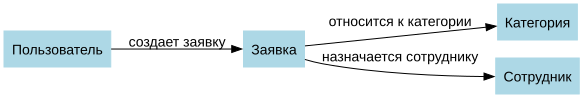

In [72]:
class_graph = build_class_ontology_graph()
class_graph

In [73]:
def build_instance_graph(users, categories, staff, tickets, limit=10):
    dot = Digraph(comment="Примеры экземпляров онтологии", format="png")
    dot.attr(rankdir="LR", fontsize="10")

    dot.attr("node", fontname="Arial")

    count = 0

    for ticket_id, ticket in tickets.items():
        if count >= limit:
            break

        ticket_node = f"ticket_{ticket_id}"
        dot.node(ticket_node, f"Заявка {ticket_id}\n{ticket.статус[0]}", shape="ellipse", style="filled", color="lightyellow")

        for category in ticket.относится_к_категории:
            category_node = category.name
            dot.node(category_node, f"Категория\n{category.название[0]}", shape="box", style="filled", color="lightpink")
            dot.edge(ticket_node, category_node, label="относится к")

        if ticket.назначается_сотруднику:
            for employee in ticket.назначается_сотруднику:
                staff_node = employee.name
                dot.node(staff_node, f"Сотрудник\n{employee.название[0]}", shape="box", style="filled", color="lightgreen")
                dot.edge(ticket_node, staff_node, label="назначена")

        for user in onto.Пользователь.instances():
            if ticket in user.создает_заявку:
                user_node = user.name
                dot.node(user_node, f"Пользователь\n{user.название[0]}", shape="box", style="filled", color="lightblue")
                dot.edge(user_node, ticket_node, label="создает")
                break

        count += 1

    return dot

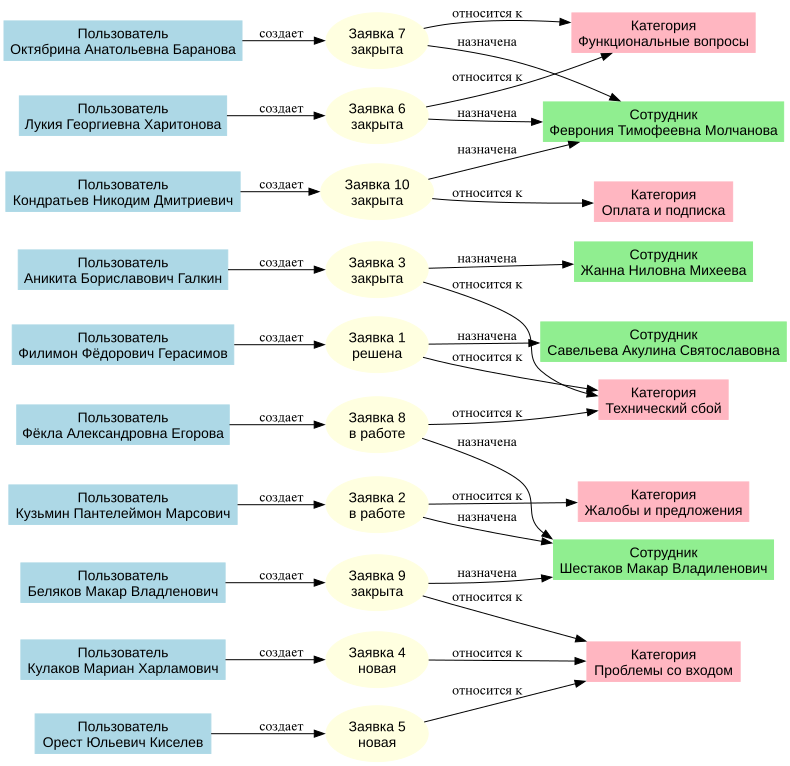

In [74]:
instance_graph = build_instance_graph(users, categories, staff, tickets, limit=10)
instance_graph